# 198. House Robber

You are a professional robber planning to rob houses along a street. Each house has a certain amount of money stashed, the only constraint stopping you from robbing each of them is that adjacent houses have security systems connected and **it will automatically contact the police if two adjacent houses were broken into on the same night**.

Given an integer array **nums** representing the amount of money of each house, return the **maximum amount of money** you can rob tonight without alerting the police.

## Example 1:

Input: nums = [1,2,3,1]

Output: 4

Explanation: Rob house 1 (money = 1) and then rob house 3 (money = 3).

Total amount you can rob = 1 + 3 = 4.

## Example 2:

Input: nums = [2,7,9,3,1]

Output: 12

Explanation: Rob house 1 (money = 2), rob house 3 (money = 9) and rob house 5 (money = 1).

Total amount you can rob = 2 + 9 + 1 = 12. 

# Specification

Input: nums = [1,2,3,1]
Rob house 1 (money == 1) and then rob 3
You can't rob house 2 (money == 2) because its adjacency

if rob nums[i] , i > 0 cannot  rob nums[i-1] and nums[i+1]

We need to maximize the money rob

## Edge case

- A intuição mais simples de pensar era pegar todos os indices pares e somar e comparar com a soma dos  indices impares, mas há casos onde maximizar vale a pena pular mais de 1 casa

- Ou seja ou pula-se 1 casa ou pula-se  2 casas em  situações específicas.

# Plan (heuristic)

nums = [3,5,15,10,15,7,20]

Vamos criar uma tabela (ou lista) dp onde dp[i] é o máximo que consigo até a casa i:

dp[0] = nums[0] = 3
dp[1] = max(nums[0], nums[1]) = max(3, 5) = 5
Agora, para cada i ≥ 2:

dp[2] = max(dp[1], nums[2] + dp[0]) = max(5, 15 + 3) = 18
dp[3] = max(dp[2], nums[3] + dp[1]) = max(18, 10 + 5) = 18
dp[4] = max(dp[3], nums[4] + dp[2]) = max(18, 15 + 18) = 33
dp[5] = max(dp[4], nums[5] + dp[3]) = max(33, 7 + 18) = 33
dp[6] = max(dp[5], nums[6] + dp[4]) = max(33, 20 + 33) = 53
Portanto, o máximo que você pode roubar é 53.

O padrão  é esse

dp[i] = max(dp[i-1], nums[i] + dp[i-2])






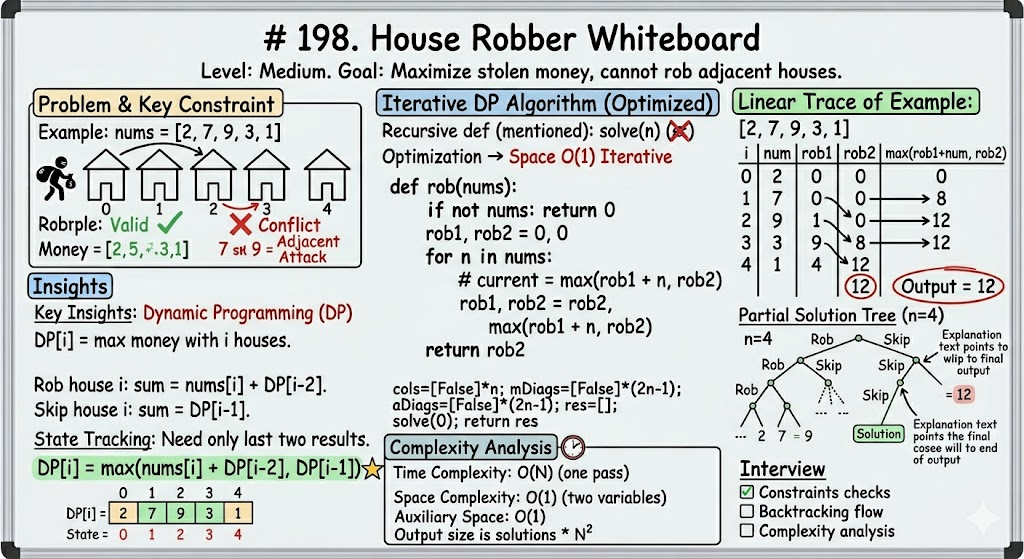

In [ ]:
from typing import List

class Solution:
    def rob(self, nums: List[int]) -> int:
        total_houses = len(nums)
        if total_houses == 0:
            return 0  # Nenhuma casa para roubar
        if total_houses == 1:
            return nums[0]  # Só uma casa, roube ela

        # dp[i] representa o máximo que posso roubar até a casa i
        dp = [0] * total_houses
        dp[0] = nums[0]
        dp[1] = max(nums[0], nums[1])

        for i in range(2, total_houses):
            # Decisão: roubar esta casa (nums[i] + dp[i-2]) ou não roubar (dp[i-1])
            dp[i] = max(dp[i-1], nums[i] + dp[i-2])  # O(N)

        return dp[-1]  # O(1)

In [ ]:
from typing import List

class Solution:
    def rob(self, nums: List[int]) -> int:
        """
        Solução otimizada em espaço O(1) usando só 2 variáveis: prev e current
        Itera diretamente sobre os valores (slice), sem índices
        """
        if not nums:
            return 0  # Sem casas
        if len(nums) == 1:
            return nums[0]  # Uma casa, roube ela
        
        # Inicializa com as duas primeiras casas
        prev = nums[0]  # Máximo até a casa 0
        current = max(nums[0], nums[1])  # Máximo até a casa 1
        
        # Itera diretamente sobre as casas a partir da 3ª (nums[2:])
        for num in nums[2:]:
          
            next = max(current, num + prev)
            
            # Shift das variáveis para a próxima iteração
            prev = current  # O que era "até i-1" vira "até i-2"
            current = next  # O que é "até i" vira "até i-1"
        
        return current  # O(1)

# Por que `for num in nums[2:]` é melhor?

**Antes (com índices):**
```python
for i in range(2, len(nums)):
    num = nums[i]
    next_max = max(current, num + prev)
```

**Depois (pythônico):**
```python
for num in nums[2:]:
    next_max = max(current, num + prev)
```

**Vantagens:**
1. **Mais legível:** Iteramos diretamente sobre valores, não índices
2. **Mais Pythônico:** Segue o padrão "for valor in sequência"
3. **Menos erro:** Sem risco de índices fora do intervalo
4. **Slice é eficiente:** `nums[2:]` cria uma view/slice (não cópia em performance crítica)

**Visual:**
```
nums = [1, 2, 3, 1]
nums[2:] = [3, 1]  # Slice com elementos a partir do índice 2

for num in nums[2:]:
    # Primeira iteração: num = 3
    # Segunda iteração: num = 1
```

**Complexity:**
- Time: O(N) (mesmo que antes)
- Space: O(1) (slice não gera cópia em Python moderno com for loop)
